1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
📢 Predicted Future Expenses for Next 7 Days:
2025-02-01: 598.63
2025-02-02: 597.91
2025-02-03: 597.89
2025-02-04: 597.89
2025-02-05: 597.89
2025-02-06: 597.89
2025-02-07: 597.89


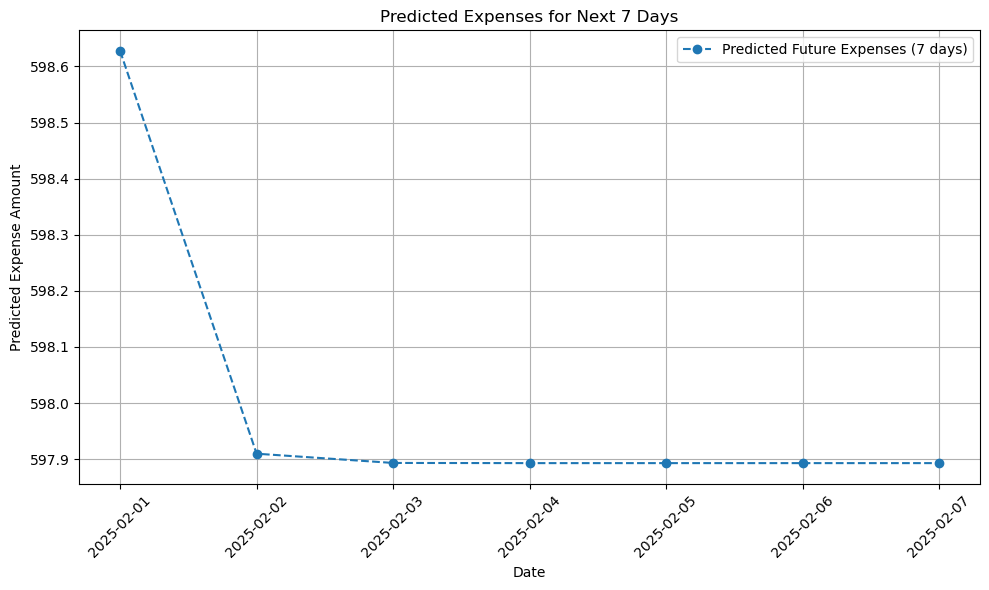

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import pickle

# 1. Load model and scaler
model = load_model('lstm_expense_predictor.h5', compile=False)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 2. Load and prepare last 30 days data
test_data = pd.read_csv('testData.csv')

# Use only 'amount'
amounts = test_data['amount'].values.reshape(-1, 1)

# Scale the data
scaled_amounts = scaler.transform(amounts)

# Reshape for LSTM input
X_input = scaled_amounts.reshape((scaled_amounts.shape[0], 1, scaled_amounts.shape[1]))

# 3. Predict the next 7 days
future_predictions = []
current_input = X_input.copy()

for _ in range(7):
    next_pred_scaled = model.predict(current_input[-1].reshape(1, 1, current_input.shape[2]))
    future_predictions.append(next_pred_scaled.flatten()[0])
    current_input = np.append(current_input, next_pred_scaled.reshape(1, 1, 1), axis=0)

# 4. Inverse transform predictions
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions_real = scaler.inverse_transform(future_predictions).flatten()

# 5. Create future dates
last_date = pd.to_datetime(test_data['Date'].iloc[-1])
future_dates = [last_date + pd.Timedelta(days=i) for i in range(1, 8)]

# 6. Print predicted expenses (as you asked)
print("📢 Predicted Future Expenses for Next 7 Days:")
for date, expense in zip(future_dates, future_predictions_real):
    print(f"{date.strftime('%Y-%m-%d')}: {expense:.2f}")

# 7. Plot only future predictions
plt.figure(figsize=(10,6))
plt.plot(future_dates, future_predictions_real, label='Predicted Future Expenses (7 days)', linestyle='--', marker='o')
plt.title('Predicted Expenses for Next 7 Days')
plt.xlabel('Date')
plt.ylabel('Predicted Expense Amount')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as mse

def plot_future_predictions(model, X_last_days, scaler, future_steps=7):
    """
    Predict future expenses and plot them.
    
    Parameters:
    model: your trained LSTM model
    X_last_days: input data for prediction (already prepared/scaled)
    scaler: fitted scaler used during training
    future_steps: number of future days to predict (default=7)
    
    Returns:
    - DataFrame with Dates and Predicted Expenses
    - List of Predicted Expenses
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # Prepare for prediction
    future_predictions = []
    current_input = X_last_days.copy()

    for _ in range(future_steps):
        next_pred_scaled = model.predict(current_input[-1].reshape(1, 1, current_input.shape[2]))
        future_predictions.append(next_pred_scaled.flatten()[0])
        current_input = np.append(current_input, next_pred_scaled.reshape(1, 1, 1), axis=0)

    # Inverse transform predictions
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    future_predictions_real = scaler.inverse_transform(future_predictions).flatten()

    # Create future dates
    last_known_date = pd.to_datetime('2025-01-31')  # You can make this dynamic
    future_dates = [last_known_date + pd.Timedelta(days=i) for i in range(1, future_steps + 1)]

    # Create a DataFrame
    future_df = pd.DataFrame({
        'Date': [date.strftime('%Y-%m-%d') for date in future_dates],
        'Predicted Expense': future_predictions_real
    })

    # Plot
    plt.figure(figsize=(10,6))
    plt.plot(future_df['Date'], future_df['Predicted Expense'], marker='o', linestyle='--', label='Predicted Expense')
    plt.title('Future Expense Predictions')
    plt.xlabel('Date')
    plt.ylabel('Expense Amount')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return future_df, future_predictions_real


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


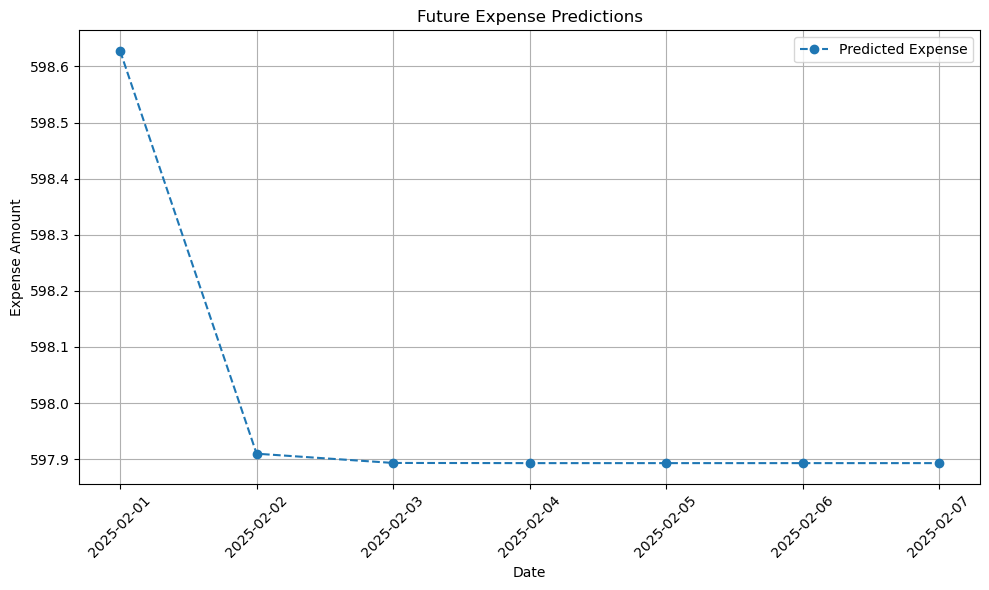

In [17]:
# Assuming you already loaded everything
# model = load_model('lstm_expense_predictor.h5', compile=False)
# scaler = pickle.load(...)
# test_data = pd.read_csv('testData.csv')

# Prepare input
amounts = test_data['amount'].values.reshape(-1, 1)
scaled_amounts = scaler.transform(amounts)
X_input = scaled_amounts.reshape((scaled_amounts.shape[0], 1, scaled_amounts.shape[1]))

# Call the function
future_df, predicted_expenses = plot_future_predictions(model, X_input, scaler)
